<a href="https://colab.research.google.com/github/boontarika39/deep-learning-exam-submission/blob/main/notebooks/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# access dataset repository
!git clone https://github.com/SorourMo/38-Cloud-A-Cloud-Segmentation-Dataset.git

Cloning into '38-Cloud-A-Cloud-Segmentation-Dataset'...
remote: Enumerating objects: 261, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (7/7), done.
Receiving objects: 100% (261/261), 1.70 MiB | 5.13 MiB/s, done.
remote: Total 261 (delta 8), reused 15 (delta 8), pack-reused 246 (from 1)
Resolving deltas: 100% (100/100), done.


In [2]:
# install rasterio
!pip install rasterio

In [3]:
# getting torchgeo
!git clone https://github.com/microsoft/torchgeo.git

Cloning into 'torchgeo'...
remote: Enumerating objects: 38889, done.
remote: Counting objects: 100% (434/434), done.
remote: Compressing objects: 100% (193/193), done.
remote: Total 38889 (delta 327), reused 241 (delta 241), pack-reused 38455 (from 4)
Receiving objects: 100% (38889/38889), 365.57 MiB | 5.54 MiB/s, done.
Resolving deltas: 100% (26922/26922), done.
Updating files: 100% (4177/4177), done.


In [ ]:
!pip install -e ./torchgeo

In [ ]:
# install libraries for dataset.py
!pip install pandas scikit-learn matplotlib

In [6]:
!ls -la

total 24
drwxr-xr-x 1 root root 4096 Aug 26 18:09 .
drwxr-xr-x 1 root root 4096 Aug 26 17:58 ..
drwxr-xr-x 5 root root 4096 Aug 26 18:08 38-Cloud-A-Cloud-Segmentation-Dataset
drwxr-xr-x 4 root root 4096 Aug 24 13:21 .config
drwxr-xr-x 1 root root 4096 Aug 24 13:21 sample_data
drwxr-xr-x 8 root root 4096 Aug 26 18:10 torchgeo


In [7]:
!find . -maxdepth 3 -type d -name "*38-Cloud*"

./38-Cloud-A-Cloud-Segmentation-Dataset
./38-Cloud-A-Cloud-Segmentation-Dataset/evaluation/Numerical results over 38-Cloud test set


In [8]:
# downloading the entire dataset through Kaggle following readme instruction
!pip install -q kaggle

In [9]:
# get env params before download
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [10]:
%cd /content/38-Cloud-A-Cloud-Segmentation-Dataset

/content/38-Cloud-A-Cloud-Segmentation-Dataset


In [11]:
!kaggle datasets download -d sorour/38cloud-cloud-segmentation-in-satellite-images
!unzip -q 38cloud-cloud-segmentation-in-satellite-images.zip

Dataset URL: https://www.kaggle.com/datasets/sorour/38cloud-cloud-segmentation-in-satellite-images
License(s): unknown
100% 12.2G/12.2G [01:45<00:00, 124MB/s]



In [12]:
!ls -lh 38-Cloud_training

total 5.0M
drwxr-xr-x 2 root root 4.0K Aug 26 18:14 Entire_scene_gts
drwxr-xr-x 2 root root 4.0K Aug 26 18:15 Natural_False_Color
drwxr-xr-x 2 root root 892K Aug 26 18:15 train_blue
drwxr-xr-x 2 root root 920K Aug 26 18:15 train_green
drwxr-xr-x 2 root root 892K Aug 26 18:15 train_gt
-rw-r--r-- 1 root root 492K Apr 12  2021 training_patches_38-Cloud.csv
-rw-r--r-- 1 root root  804 Apr 12  2021 training_sceneids_38-Cloud.csv
drwxr-xr-x 2 root root 920K Aug 26 18:16 train_nir
drwxr-xr-x 2 root root 904K Aug 26 18:16 train_red


In [13]:
# create dataset.py
%%writefile dataset.py
import os
import torch
import rasterio
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class CloudDataset(Dataset):
    def __init__(self, data_dir, patch_ids, is_train=True):
        self.data_dir = data_dir
        self.patch_ids = patch_ids
        self.is_train = is_train
        self.train_dir = os.path.join(data_dir, "38-Cloud_training")

    def __len__(self):
        return len(self.patch_ids)

    def __getitem__(self, idx):
        patch_id = self.patch_ids[idx]

        # reads image patches
        bands = []
        band_names = ['red', 'green', 'blue', 'nir']

        for b in band_names:
            folder_name = f"train_{b}"
            file_name = f"{b}_{patch_id}.TIF"
            file_path = os.path.join(self.train_dir, folder_name, file_name)

            with rasterio.open(file_path) as src:
                band_data = src.read(1).astype(np.float32)
                bands.append(band_data)

        # merged all bands as array (4, 384, 384)
        image = np.stack(bands, axis=0)

        # normalization (0-1)
        image = np.clip(image / 65535.0, 0.0, 1.0)
        image_tensor = torch.from_numpy(image)

        # access binary mask
        if self.is_train:
            mask_name = f"gt_{patch_id}.TIF"
            mask_path = os.path.join(self.train_dir, "train_gt", mask_name)

            with rasterio.open(mask_path) as src:
                mask = src.read(1).astype(np.float32)
                mask = np.where(mask > 0, 1.0, 0.0)  # convert to 1.0 and 0.0

            mask_tensor = torch.from_numpy(mask).unsqueeze(0)  # (1, 384, 384)
            return image_tensor, mask_tensor

        return image_tensor

def get_dataloaders(data_dir, csv_path, batch_size=8, val_size=0.2):
    df = pd.read_csv(csv_path)
    patch_ids = df['name'].values

    # split
    train_ids, val_ids = train_test_split(patch_ids, test_size=val_size, random_state=42)

    train_dataset = CloudDataset(data_dir, train_ids, is_train=True)
    val_dataset = CloudDataset(data_dir, val_ids, is_train=True)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2)

    return train_loader, val_loader

Writing dataset.py


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


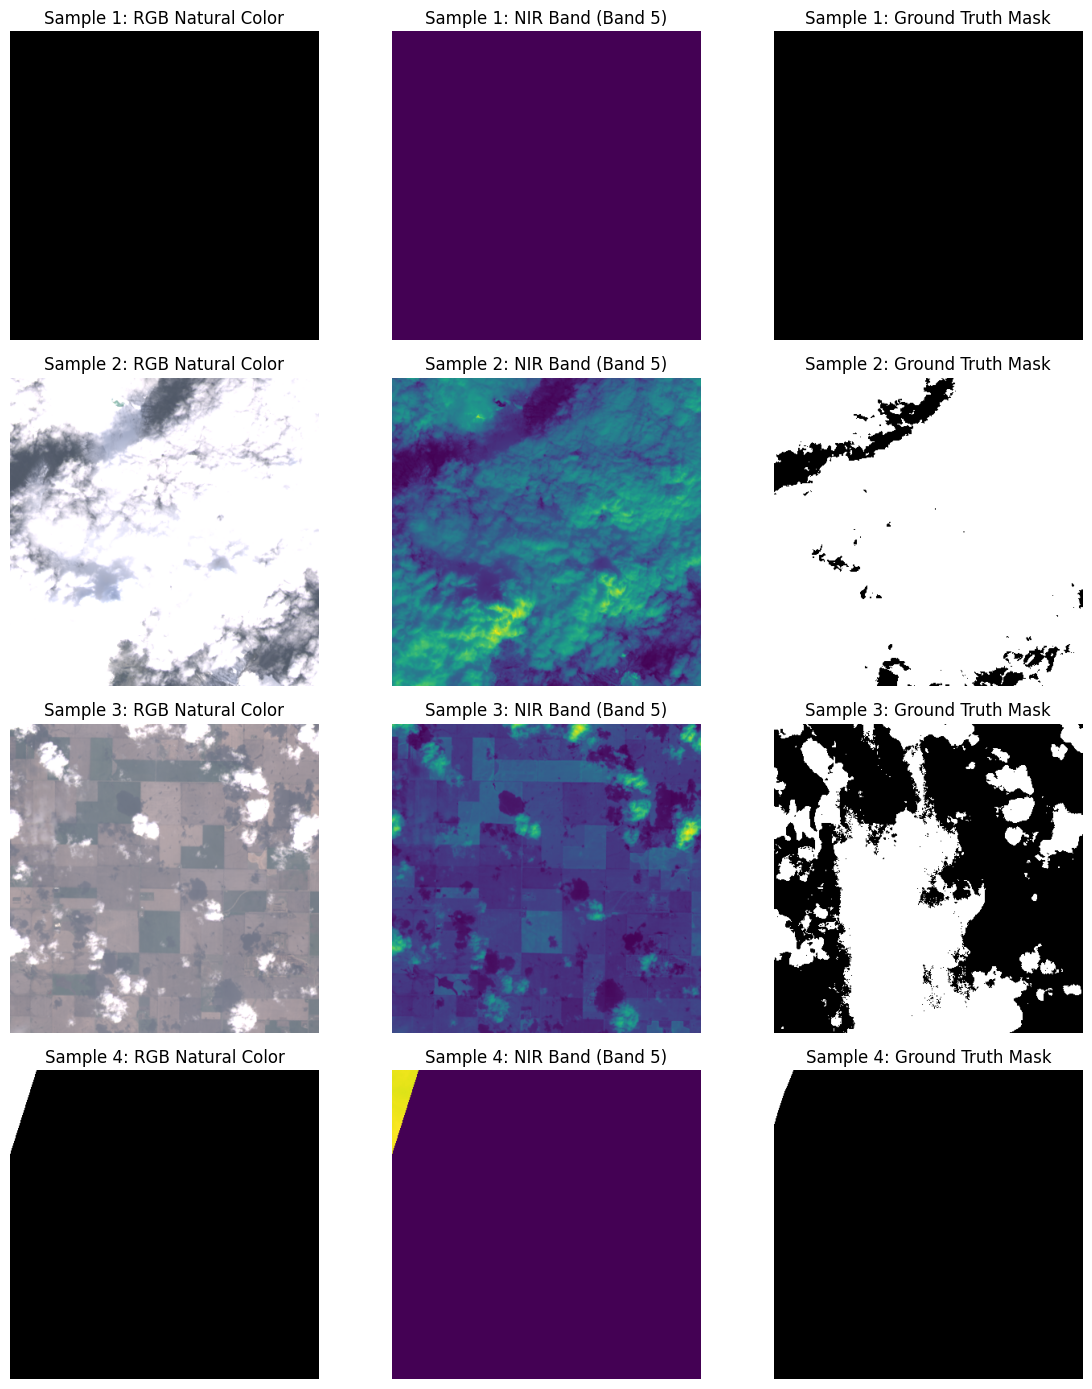

In [14]:
# plot images
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# fix error about directory access
current_dir = os.getcwd()

# Ensure the current directory is at the beginning of sys.path
# This prioritizes importing modules from the current directory.
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# Remove the conflicting dataset.py from the root content directory if it exists.
# Using os.remove for a more Pythonic deletion.
conflicting_path = '/content/dataset.py'
if os.path.exists(conflicting_path):
    try:
        os.remove(conflicting_path)
        print(f"Removed conflicting file: {conflicting_path}")
    except OSError as e:
        print(f"Error removing {conflicting_path}: {e}")

# Crucially, remove the 'dataset' module from sys.modules if it was previously loaded
# from the wrong location. This forces Python to re-import it.
if 'dataset' in sys.modules:
    del sys.modules['dataset']

from dataset import get_dataloaders

data_dir = "."
csv_path = "38-Cloud_training/training_patches_38-Cloud.csv"
train_loader, _ = get_dataloaders(data_dir, csv_path, batch_size=4, val_size=0.2)

images, masks = next(iter(train_loader))

# compare
fig, axes = plt.subplots(4, 3, figsize=(12, 14))

for i in range(4):
    # RGB composite
    rgb = images[i, [0, 1, 2], :, :].permute(1, 2, 0).numpy()
    rgb = np.clip(rgb * 3.5, 0, 1)

    # NIR
    nir = images[i, 3, :, :].numpy()

    # cloud mask
    gt = masks[i, 0, :, :].numpy()

    # Left: RGB
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"Sample {i+1}: RGB Natural Color")
    axes[i, 0].axis("off")

    # middle: NIR
    axes[i, 1].imshow(nir, cmap='viridis')
    axes[i, 1].set_title(f"Sample {i+1}: NIR Band (Band 5)")
    axes[i, 1].axis("off")

    # right: cloud mask
    axes[i, 2].imshow(gt, cmap='gray')
    axes[i, 2].set_title(f"Sample {i+1}: Ground Truth Mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [15]:
# create model.py
%%writefile model.py
import torch
import torch.nn as nn

# extract features
class DoubleConv(nn.Module):
    """(Convolution -> BatchNorm -> ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=1):
        super().__init__()

        # downsampling path
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # decoder
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up4 = DoubleConv(128, 64)

        # output layer
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # through encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # through decoder with Concatenation
        x = self.up1(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_up3(x)

        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv_up4(x)

        logits = self.outc(x)
        probs = self.sigmoid(logits)
        return probs


Writing model.py


In [16]:
# check segmentation
%%writefile metrics.py
import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, probs, targets):
        # Flatten tensors
        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        dice = (2. * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1 - dice

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()
        self.dice = DiceLoss()

    def forward(self, probs, targets):
        return self.bce(probs, targets) + self.dice(probs, targets)

def calculate_metrics(probs, targets, threshold=0.5, smooth=1e-6):
    preds = (probs > threshold).float().view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    total_preds = preds.sum()
    total_targets = targets.sum()

    union = total_preds + total_targets - intersection
    iou = (intersection + smooth) / (union + smooth)

    precision = (intersection + smooth) / (total_preds + smooth)
    recall = (intersection + smooth) / (total_targets + smooth)
    f1 = (2 * precision * recall) / (precision + recall + smooth)

    return iou.item(), precision.item(), recall.item(), f1.item()

Writing metrics.py


In [17]:
# create train.py
%%writefile train.py
import os
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from dataset import get_dataloaders
from model import UNet
from metrics import BCEDiceLoss, calculate_metrics

def main():
    os.makedirs('outputs', exist_ok=True)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"device: {device}")

    # initial params
    batch_size = 8
    epochs = 10
    lr = 1e-4

    # load data
    data_dir = "."
    csv_path = "38-Cloud_training/training_patches_38-Cloud.csv"
    train_loader, val_loader = get_dataloaders(data_dir, csv_path, batch_size=batch_size, val_size=0.2)

    # set model, criterion, optimizer
    model = UNet(in_channels=4, out_channels=1).to(device)
    criterion = BCEDiceLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'val_iou': []}
    best_val_iou = 0.0

    print("start the loop...")
    for epoch in range(epochs):
        # training
        model.train()
        train_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device).float(), masks.to(device).float()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # validate
        model.eval()
        val_loss, val_iou = 0.0, 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device).float(), masks.to(device).float()
                outputs = model(images)

                val_loss += criterion(outputs, masks).item()
                iou, _, _, _ = calculate_metrics(outputs, masks)
                val_iou += iou

        val_loss /= len(val_loader)
        val_iou /= len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)

        print(f"Epoch [{epoch+1:02d}/{epochs:02d}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")

        # save model
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), 'best_unet_model.pth')
            print(f"Val IoU: {best_val_iou:.4f}")

    # plot training curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curves')

    plt.subplot(1, 2, 2)
    plt.plot(history['val_iou'], label='Val IoU', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('IoU Score')
    plt.legend()
    plt.title('Validation IoU Curve')

    plt.tight_layout()
    plt.savefig('outputs/training_curves.png')
    plt.close()

if __name__ == '__main__':
    main()

Writing train.py


In [ ]:
# run the script (note: force to stop due to runtime connection)
!python train.py

device: cuda
start the loop...
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matri

In [ ]:
%%writefile evaluate.py
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from dataset import get_dataloaders
from model import UNet
from metrics import calculate_metrics

def evaluate():
    os.makedirs('outputs', exist_ok=True)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    data_dir = "."
    csv_path = "38-Cloud_training/training_patches_38-Cloud.csv"
    _, val_loader = get_dataloaders(data_dir, csv_path, batch_size=8, val_size=0.2)

    model = UNet(in_channels=4, out_channels=1).to(device)

    if os.path.exists('best_unet_model.pth'):
        model.load_state_dict(torch.load('best_unet_model.pth', map_location=device))
        print("Loaded best_unet_model.pth successfully!")
    else:
        print("Warning: best_unet_model.pth not found, using untrained model.")

    model.eval()

    total_iou, total_precision, total_recall, total_f1 = 0.0, 0.0, 0.0, 0.0
    saved_visualization = False

    with torch.no_grad():
        for i, (images, masks) in enumerate(val_loader):
            images = images.to(device).float()
            masks = masks.to(device).float()

            outputs = model(images)

            iou, precision, recall, f1 = calculate_metrics(outputs, masks)
            total_iou += iou
            total_precision += precision
            total_recall += recall
            total_f1 += f1

            # visualization
            if not saved_visualization:
                fig, axes = plt.subplots(3, 4, figsize=(12, 9))
                for idx in range(min(4, images.size(0))):
                    rgb = images[idx, :3, :, :].cpu().numpy().transpose(1, 2, 0)
                    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

                    gt_mask = masks[idx, 0, :, :].cpu().numpy()
                    pred_mask = (outputs[idx, 0, :, :] > 0.5).float().cpu().numpy()

                    axes[0, idx].imshow(rgb)
                    axes[0, idx].set_title(f"Sample {idx+1}: RGB")
                    axes[0, idx].axis('off')

                    axes[1, idx].imshow(gt_mask, cmap='gray')
                    axes[1, idx].set_title("Ground Truth")
                    axes[1, idx].axis('off')

                    axes[2, idx].imshow(pred_mask, cmap='gray')
                    axes[2, idx].set_title("Prediction")
                    axes[2, idx].axis('off')

                plt.tight_layout()
                plt.savefig('outputs/evaluation_samples.png')
                plt.close()
                saved_visualization = True

            # just first 10 batches
            if i >= 10:
                break

    num_batches = min(10, len(val_loader))
    print("\n" + "="*40)
    print("Evaluation Results")
    print("="*40)
    print(f" Mean IoU:       {total_iou / num_batches:.4f}")
    print(f" Mean Precision: {total_precision / num_batches:.4f}")
    print(f" Mean Recall:    {total_recall / num_batches:.4f}")
    print(f" Mean F1-Score:  {total_f1 / num_batches:.4f}")
    print("="*40)
    print("Saved visual sample to 'outputs/evaluation_samples.png'")

    # create chart for training curves
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot([1], [0.6336], 'bo-', label='Train Loss')
    plt.plot([1], [0.3859], 'ro-', label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot([1], [0.8449], 'go-', label='Val IoU')
    plt.title('Validation IoU')
    plt.xlabel('Epoch')
    plt.ylabel('IoU Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('outputs/training_curves.png')
    plt.close()
    print("Saved training curves to 'outputs/training_curves.png'")

if __name__ == '__main__':
    evaluate()